In [1]:
import pandas as pd     
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from imblearn.over_sampling import ADASYN
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                              average_precision_score, f1_score,
                              fbeta_score, recall_score, precision_score,
                              classification_report)
import matplotlib.gridspec as gridspec
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (fbeta_score, make_scorer, classification_report,
                              ConfusionMatrixDisplay, recall_score,
                              precision_score, f1_score)

In [2]:
marketing = pd.read_csv("marketing_campaign.csv", sep=';')
display(marketing.head(10))
print(marketing.info())
print(marketing.isnull().sum())   
#print(marketing.describe())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,2012-11-13,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,2013-05-08,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,2013-06-06,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,2014-03-13,68,28,...,20,1,0,0,0,0,0,3,11,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [3]:
#Nahradenie prázdnych hodnôt v Income mediánom
income_median = marketing["Income"].median()
marketing["Income"] = marketing["Income"].fillna(income_median)
print(f"Počet prázndnych hodnôt v Income: {marketing["Income"].isna().sum()}")

#Zmena Dt_Customer na datetime
marketing["Dt_Customer"] = pd.to_datetime(marketing["Dt_Customer"])
print(marketing["Dt_Customer"].dtype)
print("Najstarší dátum", marketing["Dt_Customer"].min())
print("Najnovší dátum:", marketing["Dt_Customer"].max())

latest_date = marketing["Dt_Customer"].max()
#Vypočítanie počtu dní od registrácie zákazníka po tento dátum
marketing["Customer_Tenure_Days"] = (latest_date - marketing["Dt_Customer"]).dt.days

Počet prázndnych hodnôt v Income: 0
datetime64[ns]
Najstarší dátum 2012-07-30 00:00:00
Najnovší dátum: 2014-06-29 00:00:00


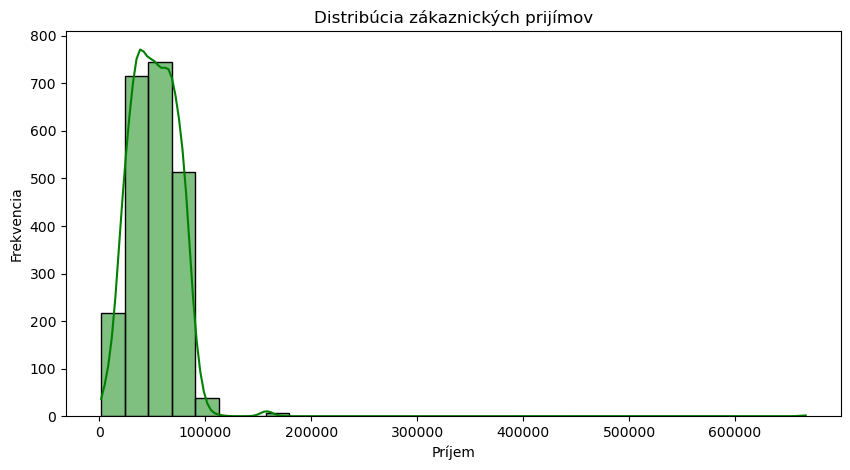

In [4]:
#graf zakaznickych príjmov
plt.figure(figsize=(10,5))
sns.histplot(marketing["Income"], bins=30, kde=True, color="green")
plt.title("Distribúcia zákaznických prijímov")
plt.xlabel("Príjem")
plt.ylabel("Frekvencia")
plt.show()

In [5]:
#Pridanie stĺpca na Vek
marketing['Age'] = 2014 - marketing["Year_Birth"]
#Recency už v datasete mám
#Frequency
purch_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
marketing["Frequency"] = marketing[purch_cols].sum(axis=1)
#Monetary
mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
marketing["Monetary"] = marketing[mnt_cols].sum(axis=1)

#RFM score (pomocou qcut)
#čím menšia recency tým lepšie
marketing['R_Score'] = pd.qcut(marketing["Recency"], 5, labels=[5, 4, 3, 2, 1])
#čim viac nákupov tým lepšie (rank kvôli duplicitným hodnotám)
marketing["F_Score"] = pd.qcut(marketing["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
#čím vyššia útrata tým lepšie
marketing["M_Score"] = pd.qcut(marketing["Monetary"], 5, labels=[1, 2, 3, 4, 5])

marketing[["R_Score", "F_Score", "M_Score"]] = marketing[["R_Score", "F_Score", "M_Score"]].astype(int)
#Súčet skóre pre ďalšiu analýzu (15 = ideálny zákazník)
marketing["RFM_Sum"] = marketing["R_Score"] + marketing["F_Score"] + marketing["M_Score"]

#Reťazec na segmentáciu
marketing["RFM_Class"] = marketing["R_Score"].astype(str) + marketing["F_Score"].astype(str) + marketing["M_Score"].astype(str)

#Ukáže priemernú úspešnosť kampane pre každú úroveň RFM súčtu
print(marketing.groupby('RFM_Sum')['Response'].mean())



display(marketing.head())

RFM_Sum
3     0.000000
4     0.029412
5     0.033149
6     0.066298
7     0.073770
8     0.121053
9     0.150628
10    0.129464
11    0.180147
12    0.235000
13    0.254658
14    0.395833
15    0.433333
Name: Response, dtype: float64


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Customer_Tenure_Days,Age,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Sum,RFM_Class
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,1,663,57,22,1617,3,5,5,13,355
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,113,60,4,27,4,1,1,6,411
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,312,49,20,776,4,4,4,12,444
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,139,30,6,53,4,2,1,7,421
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,161,33,14,422,1,3,3,7,133


In [6]:
#zobrazenie unikátnych hodnôt
print(marketing['Education'].unique())
print(marketing['Marital_Status'].unique())

#Categorical Encoding:
#manuálne mapovanie vzdelania
edu_mapping = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
marketing['Education'] = marketing['Education'].map(edu_mapping)

#get dummies pre rodinný stav
marketing = pd.get_dummies(marketing, columns=['Marital_Status'])

marketing.drop(columns=['ID'], inplace=True)

display(marketing.head())

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,RFM_Sum,RFM_Class,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,1957,2,58138.0,0,0,2012-09-04,58,635,88,546,...,13,355,False,False,False,False,True,False,False,False
1,1954,2,46344.0,1,1,2014-03-08,38,11,1,6,...,6,411,False,False,False,False,True,False,False,False
2,1965,2,71613.0,0,0,2013-08-21,26,426,49,127,...,12,444,False,False,False,False,False,True,False,False
3,1984,2,26646.0,1,0,2014-02-10,26,11,4,20,...,7,421,False,False,False,False,False,True,False,False
4,1981,4,58293.0,1,0,2014-01-19,94,173,43,118,...,7,133,False,False,False,True,False,False,False,False


In [7]:
# rozdelenie na train test split (80/20)
# X (vstupy) a y (cieľ)
X = marketing.drop(["Response","Dt_Customer"], axis=1)
y = marketing["Response"]
# strarify zariadi že pomer 0 a 1 bude v oboch množinách rovnaký
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#kontrola rozmerov
print(f"Trénovacia množina: {X_train.shape}")
print(f"Testovacia množina: {X_test.shape}")

display(marketing.head())

Trénovacia množina: (1792, 42)
Testovacia množina: (448, 42)


,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,RFM_Sum,RFM_Class,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,1957,2,58138.0,0,0,2012-09-04,58,635,88,546,...,13,355,False,False,False,False,True,False,False,False
1,1954,2,46344.0,1,1,2014-03-08,38,11,1,6,...,6,411,False,False,False,False,True,False,False,False
2,1965,2,71613.0,0,0,2013-08-21,26,426,49,127,...,12,444,False,False,False,False,False,True,False,False
3,1984,2,26646.0,1,0,2014-02-10,26,11,4,20,...,7,421,False,False,False,False,False,True,False,False
4,1981,4,58293.0,1,0,2014-01-19,94,173,43,118,...,7,133,False,False,False,True,False,False,False,False


In [8]:
# Inicializácia modelov
log_reg = LogisticRegression(max_iter=1000)
dec_tree = DecisionTreeClassifier(random_state=42)

# Trénovanie
log_reg.fit(X_train, y_train)
dec_tree.fit(X_train, y_train)

# Predikcie
log_pred = log_reg.predict(X_test)
tree_pred = dec_tree.predict(X_test)

print("--- LOGISTICKÁ REGRESIA ---")
print(f"Accuracy: {accuracy_score(y_test, log_pred):.4f}")
print(classification_report(y_test, log_pred))

print("\n--- ROZHODOVACÍ STROM ---")
print(f"Accuracy: {accuracy_score(y_test, tree_pred):.4f}")
print(classification_report(y_test, tree_pred))

--- LOGISTICKÁ REGRESIA ---
Accuracy: 0.8571
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       381
           1       0.58      0.16      0.26        67

    accuracy                           0.86       448
   macro avg       0.72      0.57      0.59       448
weighted avg       0.83      0.86      0.82       448


--- ROZHODOVACÍ STROM ---
Accuracy: 0.8214
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       381
           1       0.40      0.37      0.38        67

    accuracy                           0.82       448
   macro avg       0.64      0.64      0.64       448
weighted avg       0.82      0.82      0.82       448



C:\Users\Tomas\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


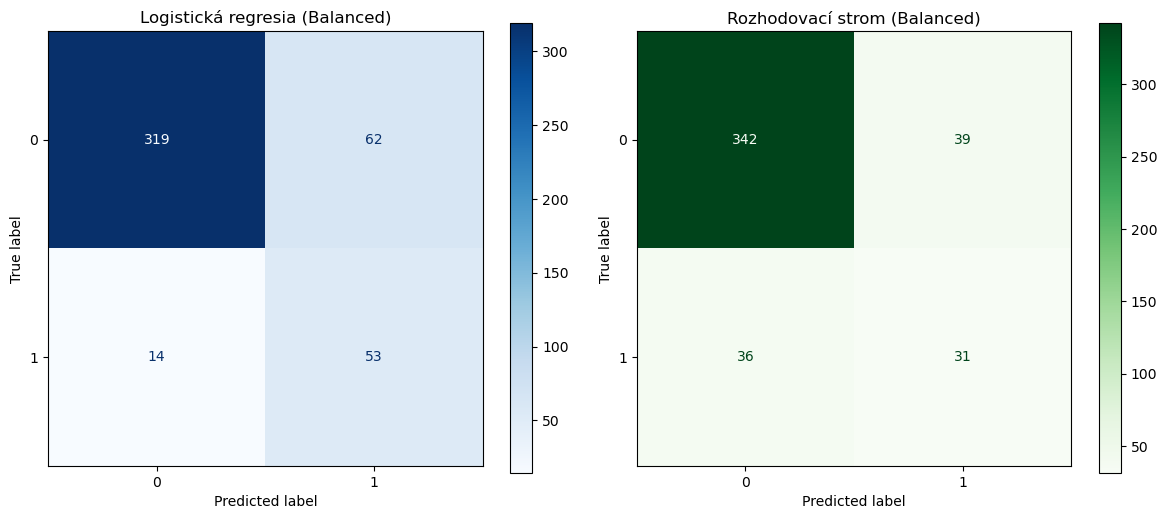

LOGISTICKÁ REGRESIA REPORT:
               precision    recall  f1-score   support

           0       0.96      0.84      0.89       381
           1       0.46      0.79      0.58        67

    accuracy                           0.83       448
   macro avg       0.71      0.81      0.74       448
weighted avg       0.88      0.83      0.85       448

ROZHODOVACÍ STROM REPORT:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90       381
           1       0.44      0.46      0.45        67

    accuracy                           0.83       448
   macro avg       0.67      0.68      0.68       448
weighted avg       0.84      0.83      0.83       448



In [9]:
#Základné balancovanie dát
# 1.StandardScaler hlavne kvôli Logistickej regresii
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Inicializácia modelov s vážením tried (class_weight="balanced" povie modelu, že Response=1 je dôležitejšia trieda)
log_reg_bal = LogisticRegression(max_iter=1000, class_weight="balanced")
dec_tree_bal = DecisionTreeClassifier(random_state=42, class_weight="balanced")

#Trénovanie na škálovaných dátach
log_reg_bal.fit(X_train_scaled, y_train)
dec_tree_bal.fit(X_train_scaled, y_train)

log_pred_bal = log_reg_bal.predict(X_test_scaled)
tree_pred_bal = dec_tree_bal.predict(X_test_scaled)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

#Matica pre Logistickú regresiu
ConfusionMatrixDisplay.from_predictions(y_test, log_pred_bal, ax=ax[0], cmap='Blues')
ax[0].set_title("Logistická regresia (Balanced)")

#Matica pre Rozhodovací strom
ConfusionMatrixDisplay.from_predictions(y_test, tree_pred_bal, ax=ax[1], cmap='Greens')
ax[1].set_title("Rozhodovací strom (Balanced)")

plt.tight_layout()
plt.show()

#Textový report
print("LOGISTICKÁ REGRESIA REPORT:\n", classification_report(y_test, log_pred_bal))
print("ROZHODOVACÍ STROM REPORT:\n", classification_report(y_test, tree_pred_bal))


C:\Users\Tomas\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


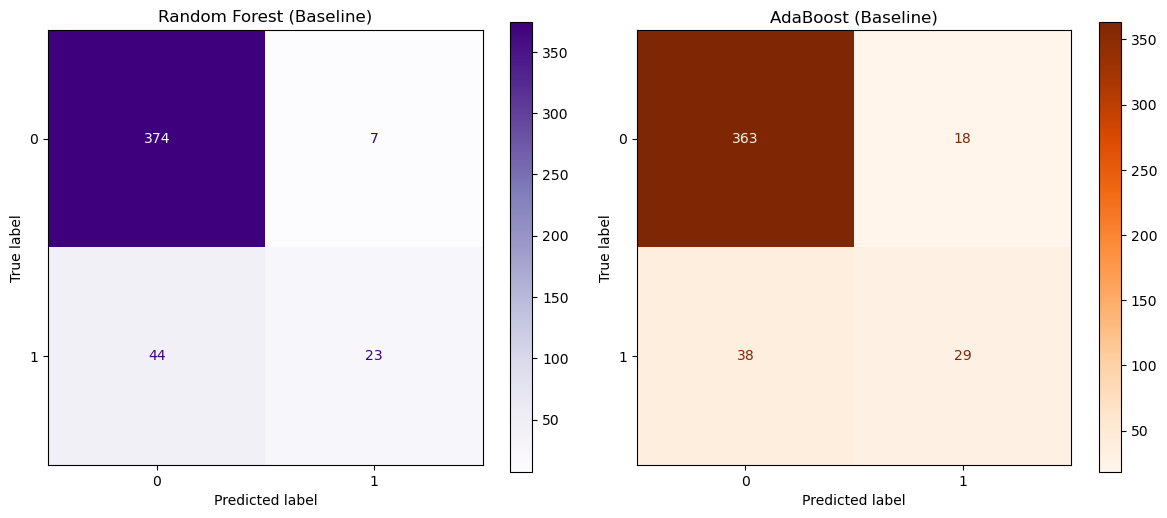

--- RANDOM FOREST (BASELINE) ---
              precision    recall  f1-score   support

           0       0.89      0.98      0.94       381
           1       0.77      0.34      0.47        67

    accuracy                           0.89       448
   macro avg       0.83      0.66      0.71       448
weighted avg       0.88      0.89      0.87       448


--- ADABOOST (BASELINE) ---
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       381
           1       0.62      0.43      0.51        67

    accuracy                           0.88       448
   macro avg       0.76      0.69      0.72       448
weighted avg       0.86      0.88      0.87       448



In [10]:
#Inicializácia základných (baseline) modelov bez použitia SMOTE
rf_base = RandomForestClassifier(random_state=42)
ada_base = AdaBoostClassifier(random_state=42)

#trénovanie
rf_base.fit(X_train_scaled, y_train)
ada_base.fit(X_train_scaled, y_train)

#Predikcie
rf_pred_base = rf_base.predict(X_test_scaled)
ada_pred_base = ada_base.predict(X_test_scaled)

#Vizualizácia cez Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

#matica pre základný Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred_base, ax=ax[0], cmap='Purples')
ax[0].set_title("Random Forest (Baseline)")
#matica pre základný AdaBoost
ConfusionMatrixDisplay.from_predictions(y_test, ada_pred_base, ax=ax[1], cmap='Oranges')
ax[1].set_title("AdaBoost (Baseline)")

plt.tight_layout()
plt.show()

#textové reporty
print("--- RANDOM FOREST (BASELINE) ---")
print(classification_report(y_test, rf_pred_base))

print("\n--- ADABOOST (BASELINE) ---")
print(classification_report(y_test, ada_pred_base))

Pôvodná trénovacia množina: (1792, 42)
Nová veľkosť po SMOTE: (3050, 42)


C:\Users\Tomas\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


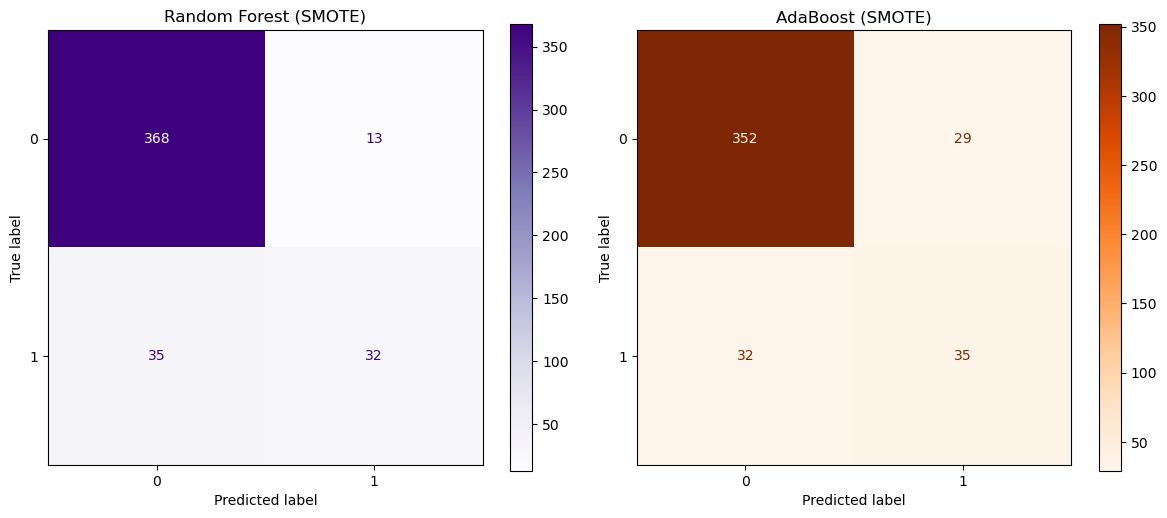

RANDOM FOREST REPORT:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94       381
           1       0.71      0.48      0.57        67

    accuracy                           0.89       448
   macro avg       0.81      0.72      0.76       448
weighted avg       0.88      0.89      0.88       448

ADABOOST REPORT:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       381
           1       0.55      0.52      0.53        67

    accuracy                           0.86       448
   macro avg       0.73      0.72      0.73       448
weighted avg       0.86      0.86      0.86       448



In [11]:
#inicializácia SMOTE
smote = SMOTE(random_state=42)

#smote na trénovacie dáta
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Pôvodná trénovacia množina: {X_train_scaled.shape}")
print(f"Nová veľkosť po SMOTE: {X_train_res.shape}")

#inicializácia modelov
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)

#trénovanie na vyvážených dátach
rf_model.fit(X_train_res, y_train_res)
ada_model.fit(X_train_res, y_train_res)

#Predikcie
rf_pred = rf_model.predict(X_test_scaled)
ada_pred = ada_model.predict(X_test_scaled)


fig, ax = plt.subplots(1, 2, figsize=(12, 5))
#random Forest
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=ax[0], cmap='Purples')
ax[0].set_title("Random Forest (SMOTE)")

#AdaBoost
ConfusionMatrixDisplay.from_predictions(y_test, ada_pred, ax=ax[1], cmap='Oranges')
ax[1].set_title("AdaBoost (SMOTE)")
plt.tight_layout()
plt.show()

print("RANDOM FOREST REPORT:\n", classification_report(y_test, rf_pred))
print("ADABOOST REPORT:\n", classification_report(y_test, ada_pred))

Pôvodná trénovacia množina: (1792, 42)
Nová veľkosť po ADASYN: (2984, 42)


C:\Users\Tomas\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


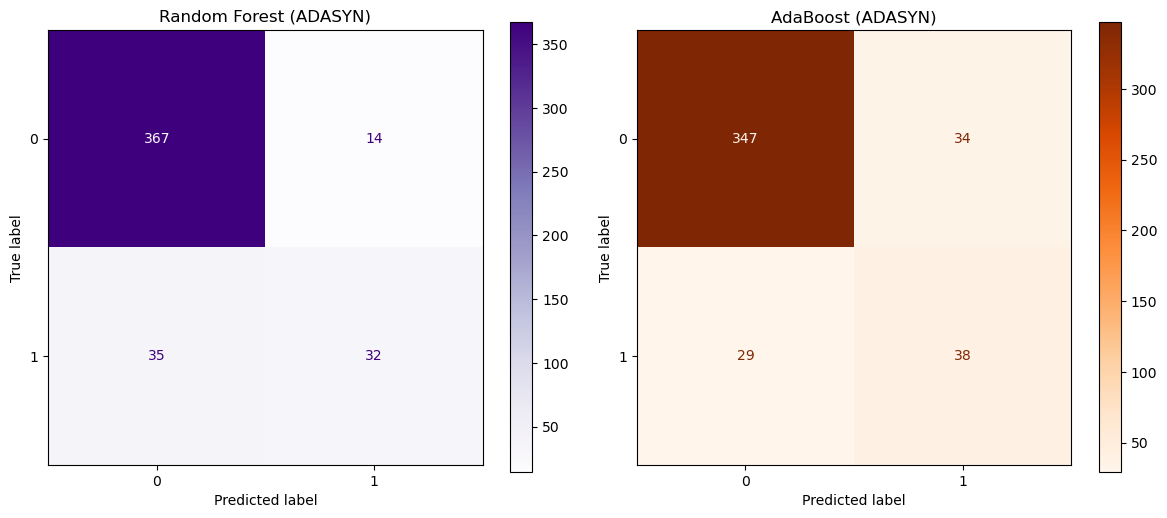

RANDOM FOREST REPORT:
               precision    recall  f1-score   support

           0       0.91      0.96      0.94       381
           1       0.70      0.48      0.57        67

    accuracy                           0.89       448
   macro avg       0.80      0.72      0.75       448
weighted avg       0.88      0.89      0.88       448

ADABOOST REPORT:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92       381
           1       0.53      0.57      0.55        67

    accuracy                           0.86       448
   macro avg       0.73      0.74      0.73       448
weighted avg       0.86      0.86      0.86       448



In [12]:
#inicializácia ADASYN
adasyn = ADASYN(random_state=42)

# ADASYN na trénovacie dáta
X_train_res, y_train_res = adasyn.fit_resample(X_train_scaled, y_train)

print(f"Pôvodná trénovacia množina: {X_train_scaled.shape}")
print(f"Nová veľkosť po ADASYN: {X_train_res.shape}")

# inicializácia modelov
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)

# trénovanie na vyvážených dátach
rf_model.fit(X_train_res, y_train_res)
ada_model.fit(X_train_res, y_train_res)

# Predikcie
rf_pred = rf_model.predict(X_test_scaled)
ada_pred = ada_model.predict(X_test_scaled)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=ax[0], cmap='Purples')
ax[0].set_title("Random Forest (ADASYN)")

# AdaBoost
ConfusionMatrixDisplay.from_predictions(y_test, ada_pred, ax=ax[1], cmap='Oranges')
ax[1].set_title("AdaBoost (ADASYN)")

plt.tight_layout()
plt.show()

print("RANDOM FOREST REPORT:\n", classification_report(y_test, rf_pred))
print("ADABOOST REPORT:\n", classification_report(y_test, ada_pred))


Pôvodná trénovacia množina: (1792, 42)
Nová veľkosť po ADASYN: (2984, 42)


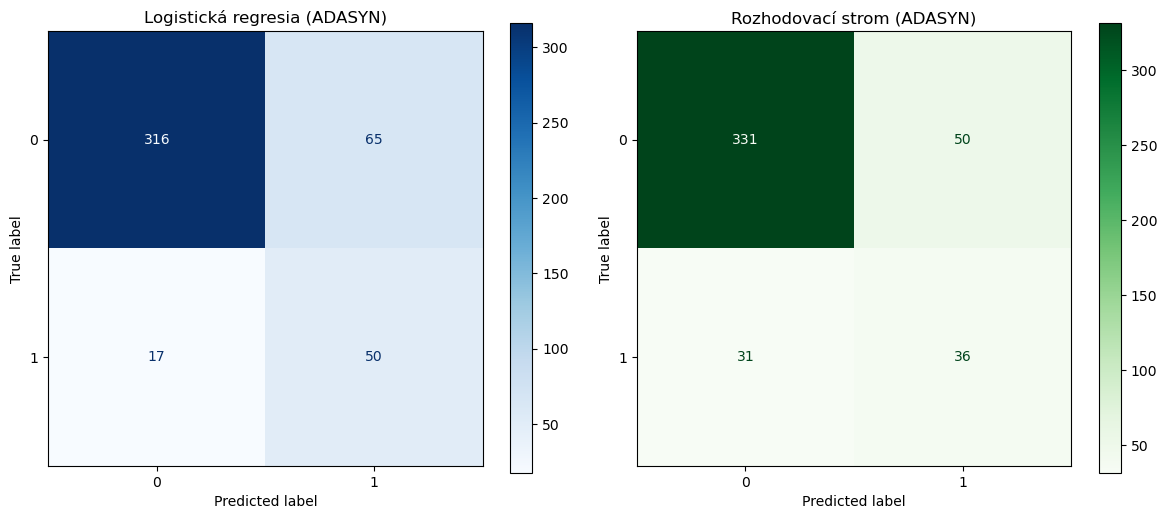

LOGISTICKÁ REGRESIA REPORT:
               precision    recall  f1-score   support

           0       0.95      0.83      0.89       381
           1       0.43      0.75      0.55        67

    accuracy                           0.82       448
   macro avg       0.69      0.79      0.72       448
weighted avg       0.87      0.82      0.83       448

ROZHODOVACÍ STROM REPORT:
               precision    recall  f1-score   support

           0       0.91      0.87      0.89       381
           1       0.42      0.54      0.47        67

    accuracy                           0.82       448
   macro avg       0.67      0.70      0.68       448
weighted avg       0.84      0.82      0.83       448



In [13]:
# 1. StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. ADASYN na trénovacie dáta (po škálovaní)
adasyn = ADASYN(random_state=42)
X_train_res, y_train_res = adasyn.fit_resample(X_train_scaled, y_train)

print(f"Pôvodná trénovacia množina: {X_train_scaled.shape}")
print(f"Nová veľkosť po ADASYN: {X_train_res.shape}")

# Inicializácia modelov - class_weight už nie je potrebný, dáta sú vyvážené cez ADASYN
log_reg_bal = LogisticRegression(max_iter=1000)
dec_tree_bal = DecisionTreeClassifier(random_state=42)

# Trénovanie na vyvážených dátach
log_reg_bal.fit(X_train_res, y_train_res)
dec_tree_bal.fit(X_train_res, y_train_res)

log_pred_bal = log_reg_bal.predict(X_test_scaled)
tree_pred_bal = dec_tree_bal.predict(X_test_scaled)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matica pre Logistickú regresiu
ConfusionMatrixDisplay.from_predictions(y_test, log_pred_bal, ax=ax[0], cmap='Blues')
ax[0].set_title("Logistická regresia (ADASYN)")

# Matica pre Rozhodovací strom
ConfusionMatrixDisplay.from_predictions(y_test, tree_pred_bal, ax=ax[1], cmap='Greens')
ax[1].set_title("Rozhodovací strom (ADASYN)")

plt.tight_layout()
plt.show()

# Textový report
print("LOGISTICKÁ REGRESIA REPORT:\n", classification_report(y_test, log_pred_bal))
print("ROZHODOVACÍ STROM REPORT:\n", classification_report(y_test, tree_pred_bal))

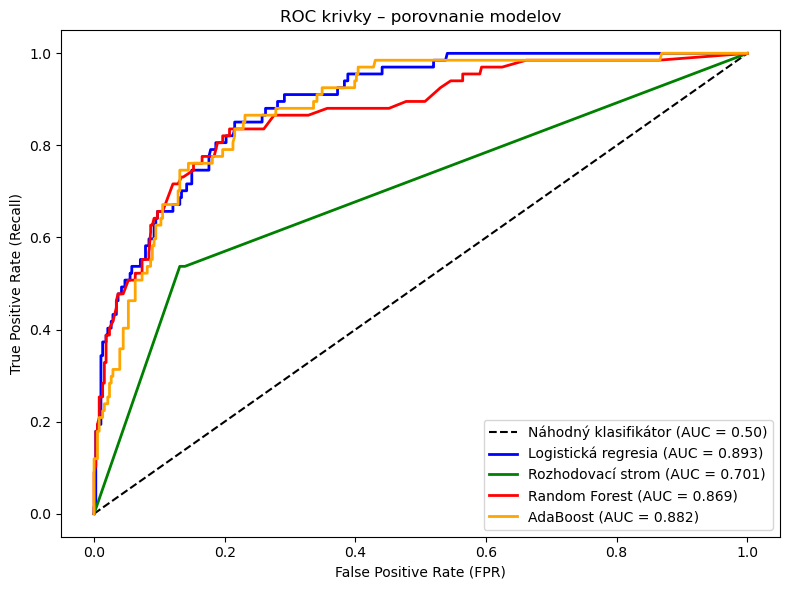

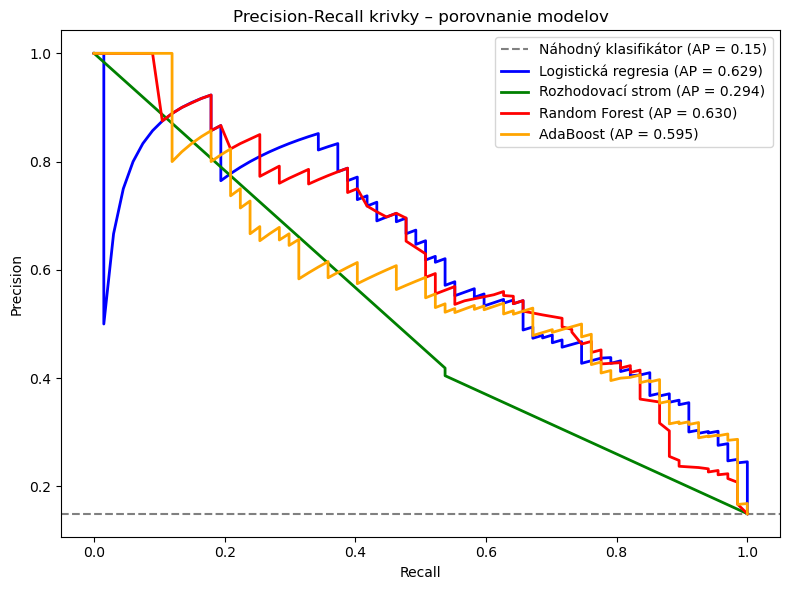

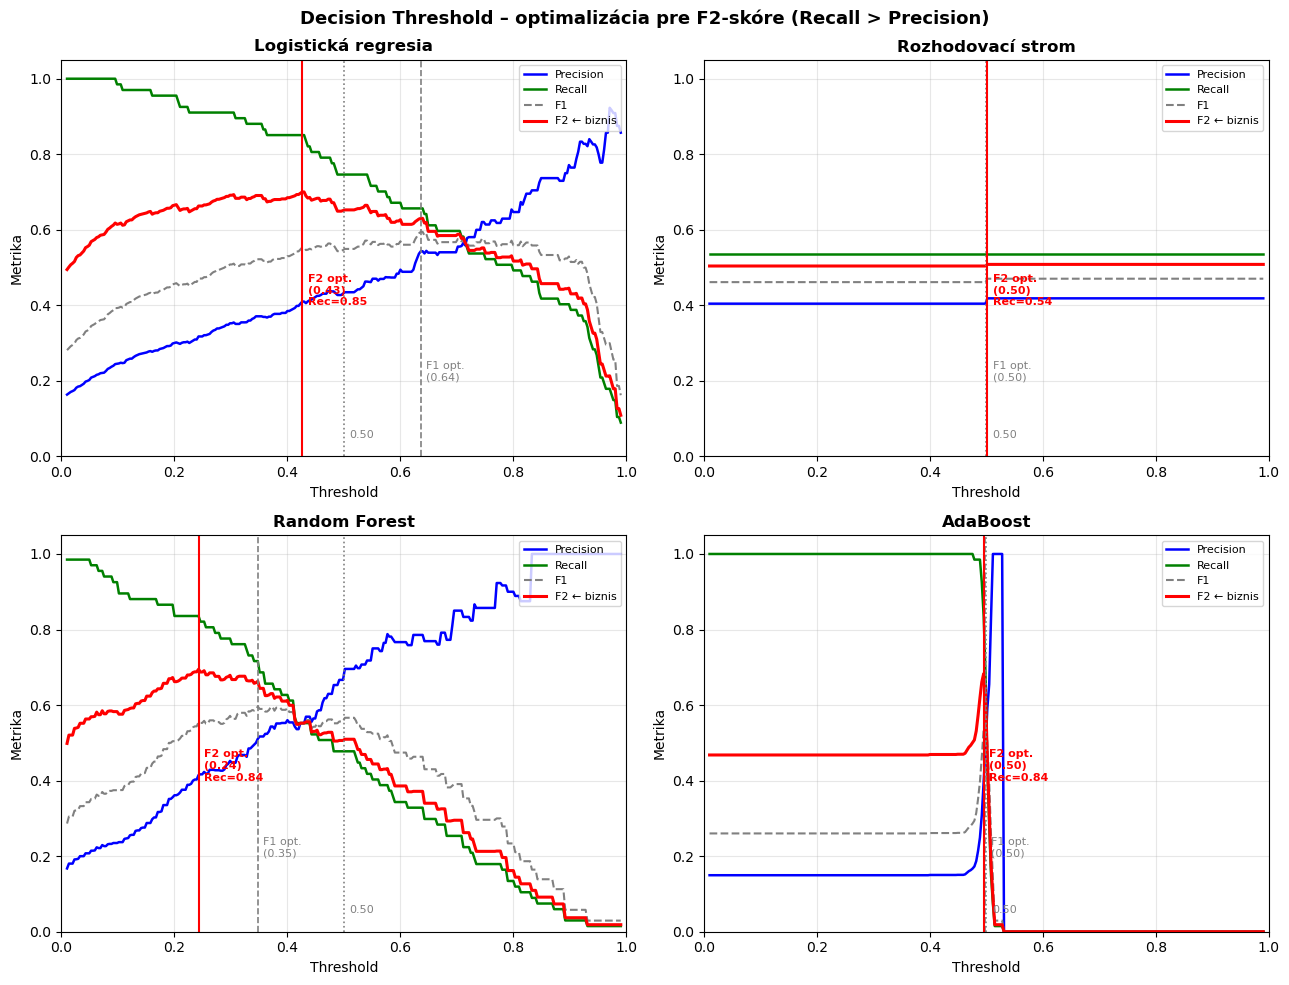

Model                      Thr   Recall   Precision       F1       F2
------------------------------------------------------------------------
Logistická regresia       0.50    0.746       0.435    0.549    0.653  
                          0.43    0.851       0.410    0.553    0.700  ← F2 opt.
------------------------------------------------------------------------
Rozhodovací strom         0.50    0.537       0.404    0.462    0.504  
                          0.50    0.537       0.419    0.471    0.508  ← F2 opt.
------------------------------------------------------------------------
Random Forest             0.50    0.478       0.667    0.557    0.506  
                          0.24    0.836       0.415    0.554    0.695  ← F2 opt.
------------------------------------------------------------------------
AdaBoost                  0.50    0.567       0.528    0.547    0.559  
                          0.50    0.836       0.394    0.536    0.683  ← F2 opt.
--------------------------

In [14]:
# ROC krivky, PR krivky & Decision Threshold analýza
# Optimalizácia pre F2-skóre (Recall má 2x väčšiu váhu ako Precision)

models = {
    'Logistická regresia': log_reg_bal,
    'Rozhodovací strom':   dec_tree_bal,
    'Random Forest':       rf_model,
    'AdaBoost':            ada_model
}
colors = ['blue', 'green', 'red', 'orange']

#časť 1: ROC krivky

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Náhodný klasifikátor (AUC = 0.50)')

for (name, model), color in zip(models.items(), colors):
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC krivky – porovnanie modelov')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


#časť 2: Precision-Recall krivky

plt.figure(figsize=(8, 6))
plt.axhline(y=y_test.mean(), color='gray', linestyle='--',
            label=f'Náhodný klasifikátor (AP = {y_test.mean():.2f})')

for (name, model), color in zip(models.items(), colors):
    proba = model.predict_proba(X_test_scaled)[:, 1]
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(rec_vals, prec_vals, color=color, linewidth=2,
             label=f'{name} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall krivky – porovnanie modelov')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


#časť 3: Decision Threshold analýza (F2-optimum)

thresholds = np.linspace(0.01, 0.99, 300)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Decision Threshold – optimalizácia pre F2-skóre (Recall > Precision)',
             fontsize=13, fontweight='bold')

for ax, (name, model) in zip(axes.flat, models.items()):
    proba = model.predict_proba(X_test_scaled)[:, 1]
    precisions, recalls, f1s, f2s = [], [], [], []

    for t in thresholds:
        preds = (proba >= t).astype(int)
        tp = ((preds == 1) & (y_test == 1)).sum()
        fp = ((preds == 1) & (y_test == 0)).sum()
        fn = ((preds == 0) & (y_test == 1)).sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        f2   = 5 * prec * rec / (4 * prec + rec) if (prec + rec) > 0 else 0
        precisions.append(prec); recalls.append(rec)
        f1s.append(f1); f2s.append(f2)

    best_t_f2 = thresholds[np.argmax(f2s)]
    best_t_f1 = thresholds[np.argmax(f1s)]

    ax.plot(thresholds, precisions, color='blue',   linewidth=1.8, label='Precision')
    ax.plot(thresholds, recalls,    color='green',  linewidth=1.8, label='Recall')
    ax.plot(thresholds, f1s,        color='gray',   linewidth=1.5, linestyle='--', label='F1')
    ax.plot(thresholds, f2s,        color='red',    linewidth=2.2, label='F2 ← biznis')

    ax.axvline(x=0.5,      color='gray', linestyle=':',  linewidth=1.2)
    ax.axvline(x=best_t_f1, color='gray', linestyle='--', linewidth=1.2)
    ax.axvline(x=best_t_f2, color='red',  linestyle='-',  linewidth=1.5)

    ax.text(0.5 + 0.01, 0.05, f'0.50', fontsize=8, color='gray')
    ax.text(best_t_f1 + 0.01, 0.20, f'F1 opt.\n({best_t_f1:.2f})', fontsize=8, color='gray')
    ax.text(best_t_f2 + 0.01, 0.40,
            f'F2 opt.\n({best_t_f2:.2f})\nRec={recalls[np.argmax(f2s)]:.2f}',
            fontsize=8, color='red', fontweight='bold')

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Metrika')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#časť 4: Porovnávacia tabuľka – default 0.5 vs F2-optimálny threshold
print("=" * 72)
print(f"{'Model':<24} {'Thr':>5}  {'Recall':>7}  {'Precision':>10}  {'F1':>7}  {'F2':>7}")
print("-" * 72)

rows = []
for name, model in models.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]

    for thr, label in [(0.50, ''), (None, '← F2 opt.')]:
        if thr is None:
            f2s  = [fbeta_score(y_test, (proba >= t).astype(int), beta=2, zero_division=0)
                    for t in thresholds]
            thr  = thresholds[np.argmax(f2s)]

        preds = (proba >= thr).astype(int)
        rec   = recall_score(y_test, preds)
        prec  = precision_score(y_test, preds, zero_division=0)
        f1    = f1_score(y_test, preds, zero_division=0)
        f2    = fbeta_score(y_test, preds, beta=2, zero_division=0)
        print(f"{name if label=='' else '':<24} {thr:>5.2f}  {rec:>7.3f}  {prec:>10.3f}  {f1:>7.3f}  {f2:>7.3f}  {label}")

        if label == '← F2 opt.':
            rows.append({'Model': name, 'F2-opt Threshold': round(thr, 2),
                         'Recall (F2-opt)': round(rec, 3), 'Precision (F2-opt)': round(prec, 3),
                         'F2 (F2-opt)': round(f2, 3)})
    print("-" * 72)


# časť 5: Classification report – najlepší model

summary_df = pd.DataFrame(rows).sort_values('Recall (F2-opt)', ascending=False)
best = summary_df.iloc[0]
best_proba = models[best['Model']].predict_proba(X_test_scaled)[:, 1]
best_preds = (best_proba >= best['F2-opt Threshold']).astype(int)

print(f"\nCLASSIFICATION REPORT – {best['Model']} @ threshold={best['F2-opt Threshold']}")
print(classification_report(y_test, best_preds, target_names=['Nereaguje (0)', 'Reaguje (1)']))

Spúšťam RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

NAJLEPŠIE HYPERPARAMETRE (F2):
  n_estimators: 400
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: None
  CV F2-skóre: 0.9549

Balanced threshold (Precision ≥ 0.5): 0.35
  → Recall:    0.701
  → Precision: 0.500

F2-optimálny threshold:  0.27
Balanced threshold:      0.35

POROVNANIE SCENÁROV:
                                 Scenár  Recall  Precision    F1    F2
A – Baseline RF              (thr=0.50)   0.478      0.696 0.566 0.510
B – Tuned RF                 (thr=0.50)   0.493      0.702 0.579 0.524
 C – Tuned RF + F2thr        (thr=0.27)   0.851      0.442 0.582 0.718
 D – Tuned RF + Balanced thr (thr=0.35)   0.701      0.500 0.584 0.649


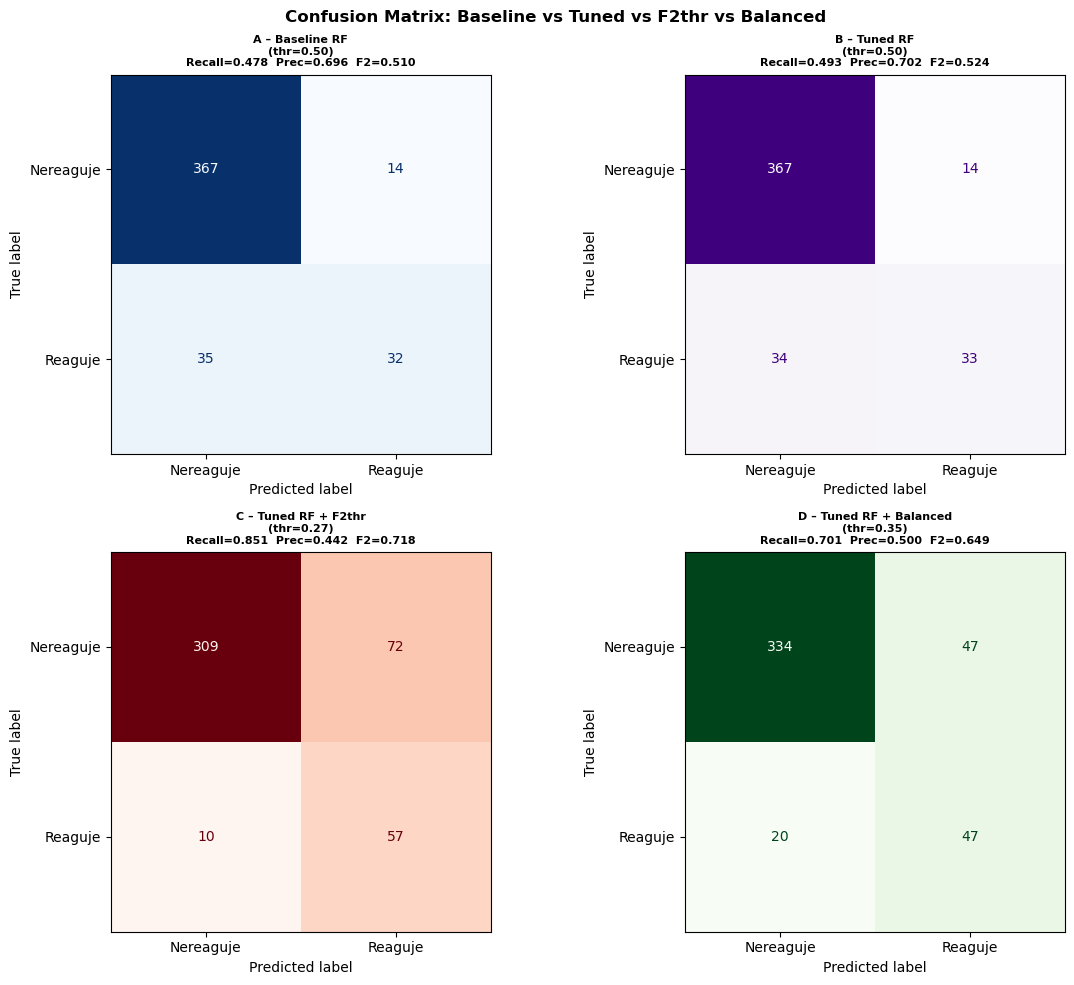

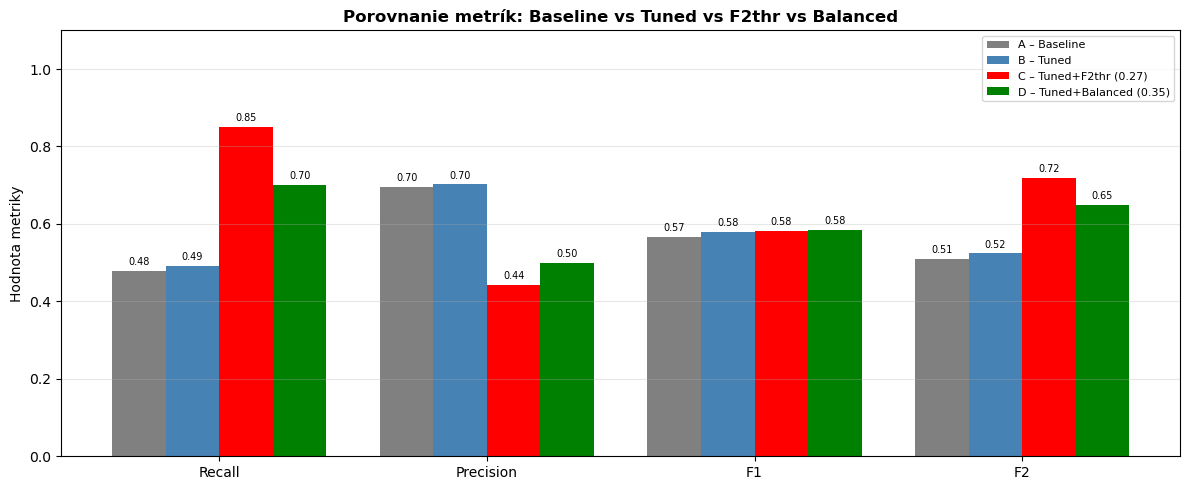

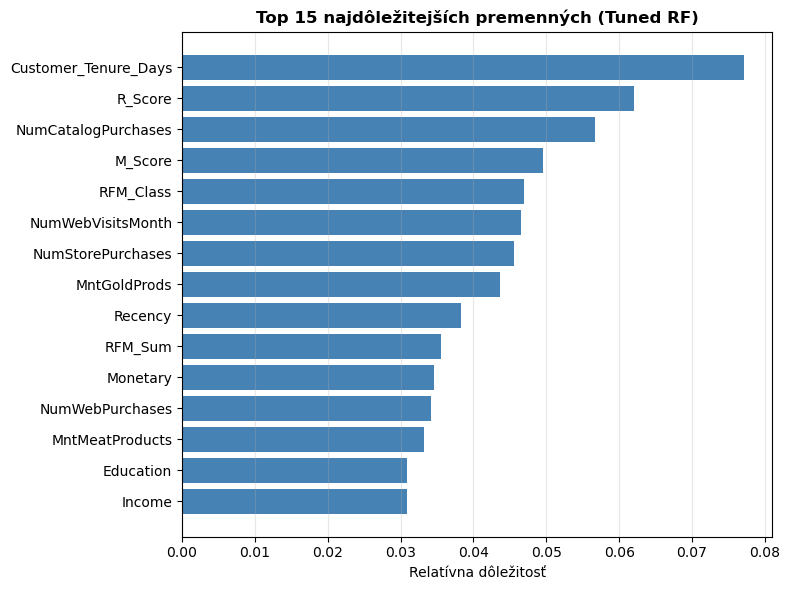


CLASSIFICATION REPORT – Scenár C (Tuned RF @ thr=0.27)
               precision    recall  f1-score   support

Nereaguje (0)       0.97      0.81      0.88       381
  Reaguje (1)       0.44      0.85      0.58        67

     accuracy                           0.82       448
    macro avg       0.71      0.83      0.73       448
 weighted avg       0.89      0.82      0.84       448


CLASSIFICATION REPORT – Scenár D (Tuned RF @ thr=0.35, Precision ≥ 0.5)
               precision    recall  f1-score   support

Nereaguje (0)       0.94      0.88      0.91       381
  Reaguje (1)       0.50      0.70      0.58        67

     accuracy                           0.85       448
    macro avg       0.72      0.79      0.75       448
 weighted avg       0.88      0.85      0.86       448



In [18]:
# Hyperparameter Tuning - Random Forest + RandomizedSearchCV
# Optimalizácia pre F2-skóre (Recall má 2x väčšiu váhu ako Precision)


#časť 1: Definícia parametrov a spustenie hľadania

param_dist = {
    'n_estimators':      [100, 200, 300, 400, 500],
    'max_depth':         [None, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf':  [1, 2, 4, 8],
    'max_features':      ['sqrt', 'log2'],
}

f2_scorer = make_scorer(fbeta_score, beta=2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42),
    param_distributions = param_dist,
    n_iter              = 50,
    cv                  = cv,
    scoring             = f2_scorer,
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1
)

print("Spúšťam RandomizedSearchCV...")
random_search.fit(X_train_res, y_train_res)
best_rf = random_search.best_estimator_


# časť 2: Výpis najlepších parametrov

print("\nNAJLEPŠIE HYPERPARAMETRE (F2):")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"  CV F2-skóre: {random_search.best_score_:.4f}")


#časť 3: Štyri scenáre - Baseline / Tuned / Tuned+F2thr / Tuned+Balanced

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train_res, y_train_res)
y_pred_baseline = rf_baseline.predict(X_test_scaled)

y_pred_tuned_05 = best_rf.predict(X_test_scaled)

proba_tuned = best_rf.predict_proba(X_test_scaled)[:, 1]
thresholds  = np.linspace(0.01, 0.99, 300)

#scenár C - F2-optimálny threshold (maximalizuje F2 bez obmedzení)
f2_scores      = [fbeta_score(y_test, (proba_tuned >= t).astype(int), beta=2, zero_division=0)
                  for t in thresholds]
best_threshold = thresholds[np.argmax(f2_scores)]
y_pred_tuned_f2 = (proba_tuned >= best_threshold).astype(int)

#scenár D - Balanced threshold (maximalizuje Recall pri Precision >= 0.50)
MIN_PRECISION = 0.50
precisions_all = [precision_score(y_test, (proba_tuned >= t).astype(int), zero_division=0)
                  for t in thresholds]
recalls_all    = [recall_score(y_test, (proba_tuned >= t).astype(int))
                  for t in thresholds]

#Z thresholdov, kde precision >= MIN_PRECISION, vyber ten s najvyšším recall
candidates = [(t, rec, prec)
              for t, rec, prec in zip(thresholds, recalls_all, precisions_all)
              if prec >= MIN_PRECISION]

if candidates:
    best_balanced_thr = max(candidates, key=lambda x: x[1])[0]
    print(f"\nBalanced threshold (Precision ≥ {MIN_PRECISION}): {best_balanced_thr:.2f}")
    print(f"  → Recall:    {recall_score(y_test, (proba_tuned >= best_balanced_thr).astype(int)):.3f}")
    print(f"  → Precision: {precision_score(y_test, (proba_tuned >= best_balanced_thr).astype(int), zero_division=0):.3f}")
else:
    print(f"\n⚠ Žiaden threshold nespĺňa Precision ≥ {MIN_PRECISION}. Skús znížiť MIN_PRECISION.")
    best_balanced_thr = best_threshold  # fallback

y_pred_balanced = (proba_tuned >= best_balanced_thr).astype(int)

print(f"\nF2-optimálny threshold:  {best_threshold:.2f}")
print(f"Balanced threshold:      {best_balanced_thr:.2f}")

# Porovnávacia tabuľka
def row(name, y_true, y_pred):
    return {'Scenár': name,
            'Recall':    round(recall_score(y_true, y_pred), 3),
            'Precision': round(precision_score(y_true, y_pred, zero_division=0), 3),
            'F1':        round(f1_score(y_true, y_pred, zero_division=0), 3),
            'F2':        round(fbeta_score(y_true, y_pred, beta=2, zero_division=0), 3)}

comparison_df = pd.DataFrame([
    row('A – Baseline RF              (thr=0.50)', y_test, y_pred_baseline),
    row('B – Tuned RF                 (thr=0.50)', y_test, y_pred_tuned_05),
    row(f'C – Tuned RF + F2thr        (thr={best_threshold:.2f})', y_test, y_pred_tuned_f2),
    row(f'D – Tuned RF + Balanced thr (thr={best_balanced_thr:.2f})', y_test, y_pred_balanced),
])
print("\nPOROVNANIE SCENÁROV:")
print(comparison_df.to_string(index=False))


# časť 4: Confusion Matrices - všetky 4 scenáre

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, preds, title, cmap in [
    (axes[0, 0], y_pred_baseline, f'A – Baseline RF\n(thr=0.50)', 'Blues'),
    (axes[0, 1], y_pred_tuned_05, f'B – Tuned RF\n(thr=0.50)', 'Purples'),
    (axes[1, 0], y_pred_tuned_f2, f'C – Tuned RF + F2thr\n(thr={best_threshold:.2f})', 'Reds'),
    (axes[1, 1], y_pred_balanced, f'D – Tuned RF + Balanced\n(thr={best_balanced_thr:.2f})', 'Greens'),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, ax=ax, cmap=cmap, colorbar=False,
        display_labels=['Nereaguje', 'Reaguje']
    )
    ax.set_title(
        f'{title}\nRecall={recall_score(y_test, preds):.3f}  '
        f'Prec={precision_score(y_test, preds, zero_division=0):.3f}  '
        f'F2={fbeta_score(y_test, preds, beta=2, zero_division=0):.3f}',
        fontweight='bold', fontsize=8
    )

plt.suptitle('Confusion Matrix: Baseline vs Tuned vs F2thr vs Balanced', fontweight='bold')
plt.tight_layout()
plt.show()


#časť 5: Stĺpcový graf metrík

metrics_names   = ['Recall', 'Precision', 'F1', 'F2']
scenario_labels = [
    'A – Baseline',
    'B – Tuned',
    f'C – Tuned+F2thr ({best_threshold:.2f})',
    f'D – Tuned+Balanced ({best_balanced_thr:.2f})',
]
scenario_colors = ['gray', 'steelblue', 'red', 'green']
scenario_preds  = [y_pred_baseline, y_pred_tuned_05, y_pred_tuned_f2, y_pred_balanced]

scenario_data = [
    [recall_score(y_test, p, zero_division=0), precision_score(y_test, p, zero_division=0),
     f1_score(y_test, p, zero_division=0),     fbeta_score(y_test, p, beta=2, zero_division=0)]
    for p in scenario_preds
]

x, width = np.arange(len(metrics_names)), 0.20
fig, ax = plt.subplots(figsize=(12, 5))
for i, (data, color, label) in enumerate(zip(scenario_data, scenario_colors, scenario_labels)):
    bars = ax.bar(x + i * width, data, width, label=label, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_names)
ax.set_ylabel('Hodnota metriky')
ax.set_title('Porovnanie metrík: Baseline vs Tuned vs F2thr vs Balanced', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# časť 6: Feature Importances - Top 15

feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': best_rf.feature_importances_})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(8, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='steelblue')
plt.title('Top 15 najdôležitejších premenných (Tuned RF)', fontweight='bold')
plt.xlabel('Relatívna dôležitosť')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# časť 7: Classification report - Scenár C a D

print(f"\nCLASSIFICATION REPORT – Scenár C (Tuned RF @ thr={best_threshold:.2f})")
print(classification_report(y_test, y_pred_tuned_f2, target_names=['Nereaguje (0)', 'Reaguje (1)']))

print(f"\nCLASSIFICATION REPORT – Scenár D (Tuned RF @ thr={best_balanced_thr:.2f}, Precision ≥ {MIN_PRECISION})")
print(classification_report(y_test, y_pred_balanced, target_names=['Nereaguje (0)', 'Reaguje (1)']))

Spúšťam RandomizedSearchCV pre všetky modely...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
✓ Random Forest hotový  |  CV F2 = 0.9549
Fitting 5 folds for each of 15 candidates, totalling 75 fits


C:\Users\Tomas\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


✓ AdaBoost hotový  |  CV F2 = 0.9184
Fitting 5 folds for each of 12 candidates, totalling 60 fits
✓ Logistická regresia hotový  |  CV F2 = 0.8401
Fitting 5 folds for each of 20 candidates, totalling 100 fits
✓ Rozhodovací strom hotový  |  CV F2 = 0.8783

NAJLEPŠIE PARAMETRE (F2):

Random Forest  |  CV F2 = 0.9549
  n_estimators: 400
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: None

AdaBoost  |  CV F2 = 0.9184
  n_estimators: 200
  learning_rate: 1.0

Logistická regresia  |  CV F2 = 0.8401
  solver: liblinear
  penalty: l2
  C: 0.01

Rozhodovací strom  |  CV F2 = 0.8783
  min_samples_split: 2
  min_samples_leaf: 1
  max_depth: 10
  criterion: entropy

POROVNANIE: BASELINE vs TUNED
              Model  Recall (Base)  Recall (Tuned)  Δ Recall  F2 (Base)  F2 (Tuned)   Δ F2
Logistická regresia          0.746           0.851     0.104      0.653       0.705  0.053
           AdaBoost          0.567           0.597     0.030      0.559       0.588  0.029
   

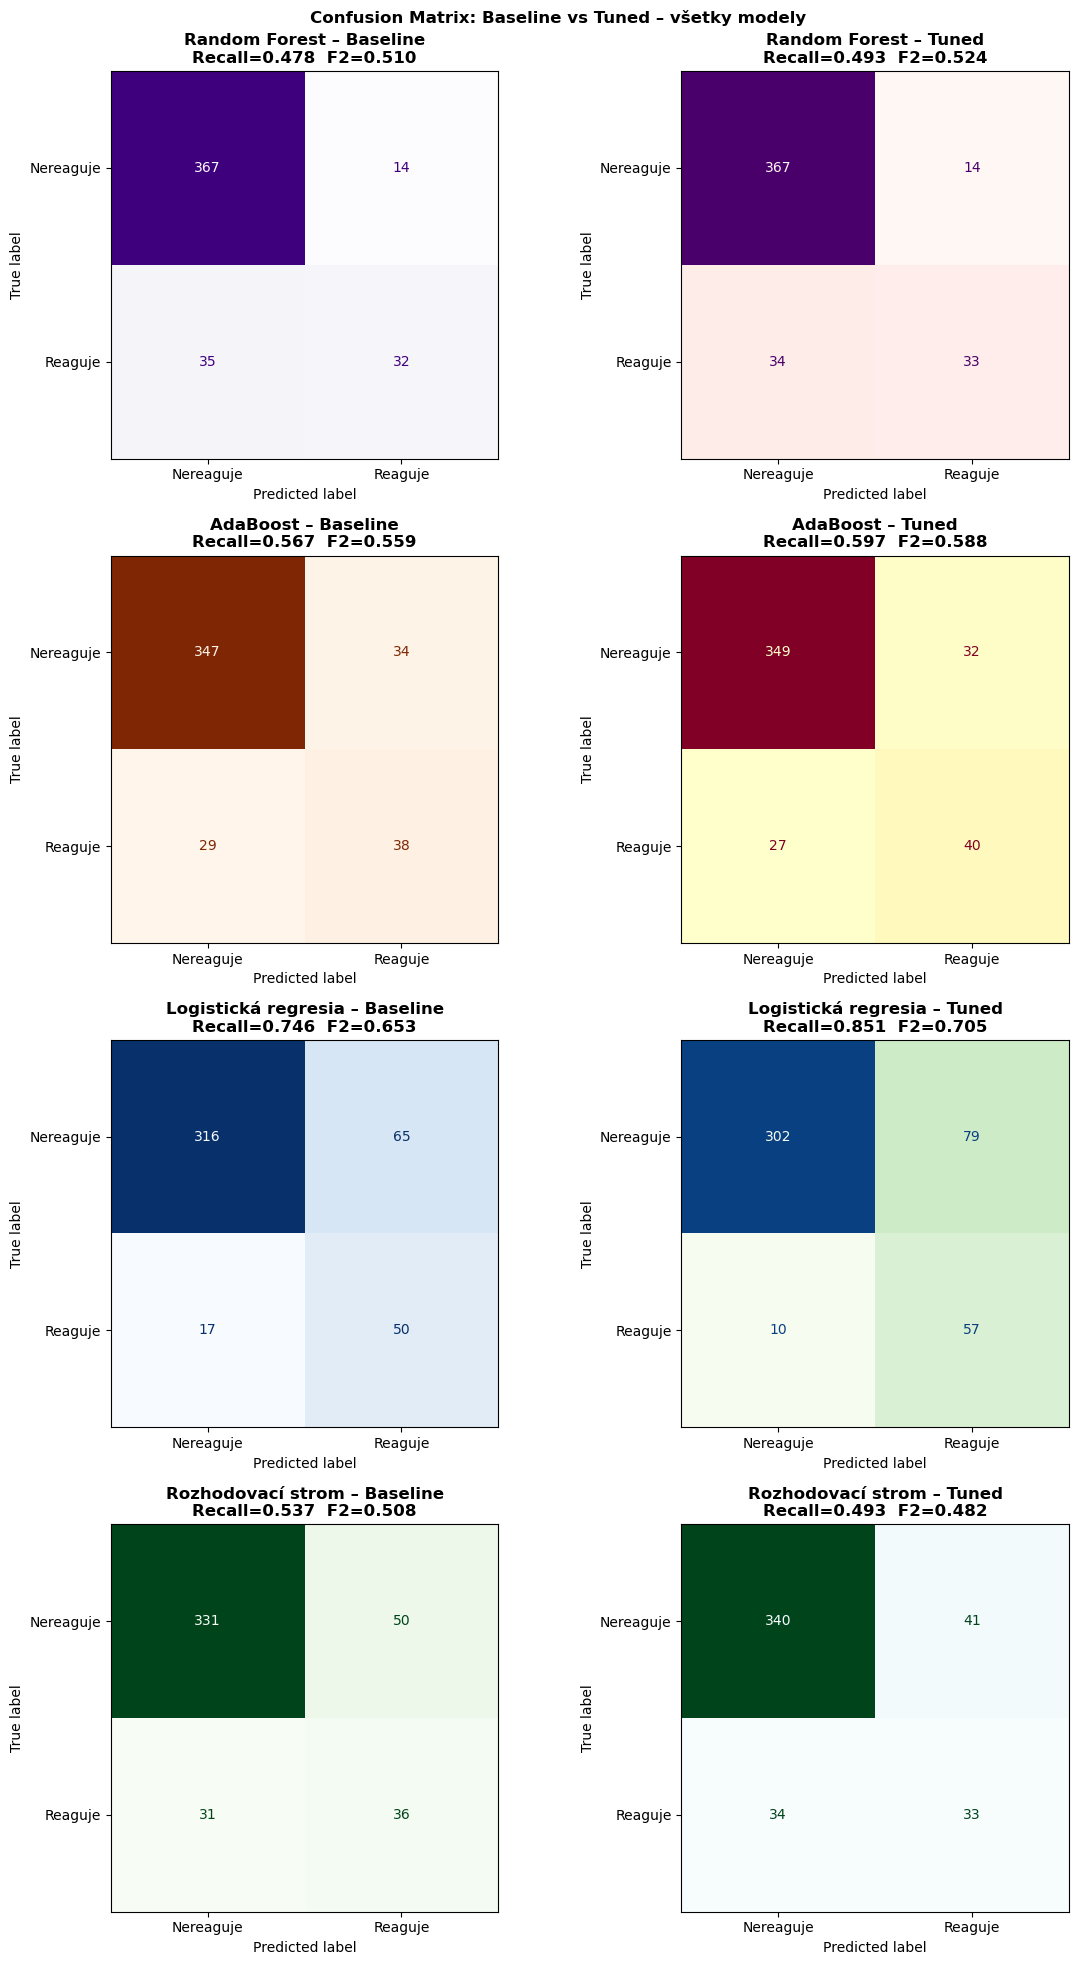

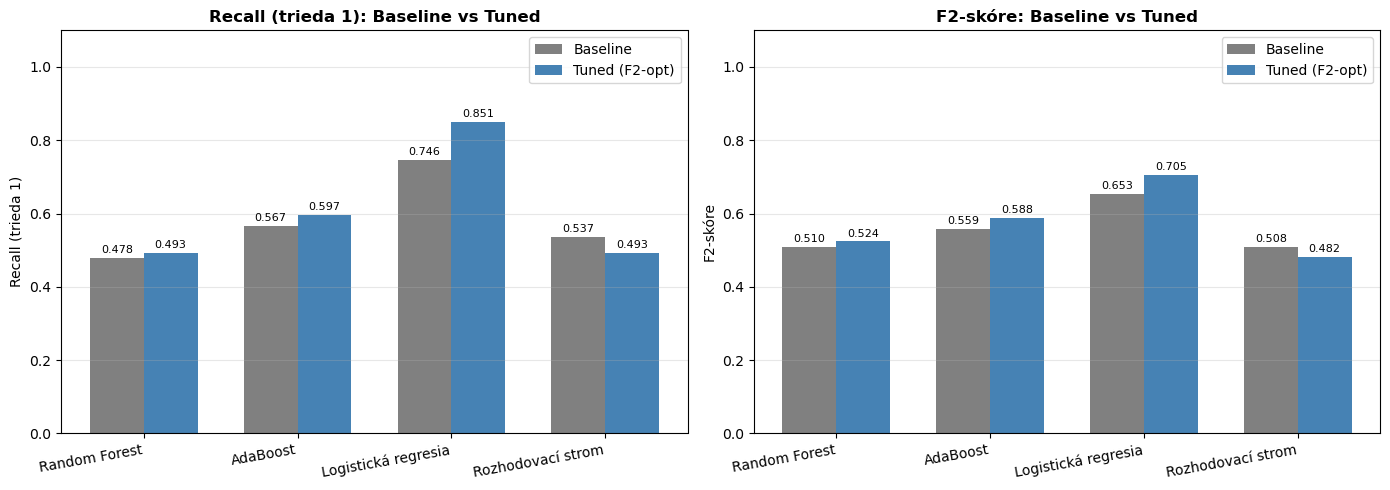


CLASSIFICATION REPORT – najlepší tuned model: Logistická regresia
               precision    recall  f1-score   support

Nereaguje (0)       0.97      0.79      0.87       381
  Reaguje (1)       0.42      0.85      0.56        67

     accuracy                           0.80       448
    macro avg       0.69      0.82      0.72       448
 weighted avg       0.89      0.80      0.83       448



In [16]:
# Hyperparameter Tuning - všetky 4 modely, RandomizedSearchCV + F2-skóre


# krok 1: Spoločné nastavenia

f2_scorer = make_scorer(fbeta_score, beta=2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


#krok 2: Priestory parametrov (class_weight vynechaný - dáta sú vyvážené cez ADASYN)

rf_param_grid = {
    'n_estimators':      [100, 200, 300, 400, 500],
    'max_depth':         [None, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf':  [1, 2, 4, 8],
    'max_features':      ['sqrt', 'log2'],
}
ada_param_grid = {
    'n_estimators':  [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
}
log_param_grid = {
    'C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear'],
}
tree_param_grid = {
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 8],
    'criterion':         ['gini', 'entropy'],
}


#krok 3: RandomizedSearchCV - všetky modely na f2_scorer

print("Spúšťam RandomizedSearchCV pre všetky modely...")

searches = {}
for estimator, params, n_iter, label in [
    (RandomForestClassifier(random_state=42),  rf_param_grid,   30, 'Random Forest'),
    (AdaBoostClassifier(random_state=42),       ada_param_grid,  15, 'AdaBoost'),
    (LogisticRegression(max_iter=1000),          log_param_grid,  12, 'Logistická regresia'),
    (DecisionTreeClassifier(random_state=42),   tree_param_grid, 20, 'Rozhodovací strom'),
]:
    search = RandomizedSearchCV(estimator, params, n_iter=n_iter,
                                cv=cv, scoring=f2_scorer, n_jobs=-1,
                                random_state=42, verbose=1)
    search.fit(X_train_res, y_train_res)
    searches[label] = search
    print(f"✓ {label} hotový  |  CV F2 = {search.best_score_:.4f}")


#krok 4: Najlepšie parametre

print("\nNAJLEPŠIE PARAMETRE (F2):")
for name, search in searches.items():
    print(f"\n{name}  |  CV F2 = {search.best_score_:.4f}")
    for param, val in search.best_params_.items():
        print(f"  {param}: {val}")


# krok 5: Predikcie

model_names     = list(searches.keys())
tuned_preds_list = [s.best_estimator_.predict(X_test_scaled) for s in searches.values()]
base_preds_list  = [rf_pred, ada_pred, log_pred_bal, tree_pred_bal]


#krok 6: Porovnávacia tabuľka - Recall + F2 ako primárne metriky

rows = []
for name, b, t in zip(model_names, base_preds_list, tuned_preds_list):
    rows.append({
        'Model':           name,
        'Recall (Base)':   round(recall_score(y_test, b), 3),
        'Recall (Tuned)':  round(recall_score(y_test, t), 3),
        'Δ Recall':        round(recall_score(y_test, t) - recall_score(y_test, b), 3),
        'F2 (Base)':       round(fbeta_score(y_test, b, beta=2, zero_division=0), 3),
        'F2 (Tuned)':      round(fbeta_score(y_test, t, beta=2, zero_division=0), 3),
        'Δ F2':            round(fbeta_score(y_test, t, beta=2, zero_division=0) -
                                 fbeta_score(y_test, b, beta=2, zero_division=0), 3),
    })

results_df = pd.DataFrame(rows).sort_values('F2 (Tuned)', ascending=False)
print("\nPOROVNANIE: BASELINE vs TUNED")
print(results_df.to_string(index=False))


#krok 7: Vizualizácie

colors_base  = ['Purples', 'Oranges', 'Blues', 'Greens']
colors_tuned = ['RdPu', 'YlOrRd', 'GnBu', 'BuGn']

#Graf 1: Confusion Matrices Baseline vs Tuned (4x2)
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
fig.suptitle('Confusion Matrix: Baseline vs Tuned – všetky modely \n', fontweight='bold')
for i, name in enumerate(model_names):
    for j, (preds, cmap, label) in enumerate([
        (base_preds_list[i],  colors_base[i],  'Baseline'),
        (tuned_preds_list[i], colors_tuned[i], 'Tuned'),
    ]):
        ConfusionMatrixDisplay.from_predictions(
            y_test, preds, ax=axes[i][j], cmap=cmap, colorbar=False,
            display_labels=['Nereaguje', 'Reaguje']
        )
        rec = recall_score(y_test, preds)
        f2  = fbeta_score(y_test, preds, beta=2, zero_division=0)
        axes[i][j].set_title(f'{name} – {label}\nRecall={rec:.3f}  F2={f2:.3f}', fontweight='bold')
plt.tight_layout()
plt.show()

#Graf 2: Recall + F2 stĺpcový graf (1x2 cez gridspec)
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig)
x, width = np.arange(len(model_names)), 0.35

for idx, (metric_fn, title) in enumerate([
    (lambda p: recall_score(y_test, p),                         'Recall (trieda 1)'),
    (lambda p: fbeta_score(y_test, p, beta=2, zero_division=0), 'F2-skóre'),
]):
    ax = fig.add_subplot(gs[0, idx])
    vals_b = [metric_fn(p) for p in base_preds_list]
    vals_t = [metric_fn(p) for p in tuned_preds_list]
    bars_b = ax.bar(x - width/2, vals_b, width, label='Baseline', color='gray')
    bars_t = ax.bar(x + width/2, vals_t, width, label='Tuned (F2-opt)', color='steelblue')
    for bar in bars_b + bars_t:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=10, ha='right')
    ax.set_title(f'{title}: Baseline vs Tuned', fontweight='bold')
    ax.set_ylabel(title)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# krok8: Classification report – najlepší model podľa F2

best_name = results_df.iloc[0]['Model']
best_pred = tuned_preds_list[model_names.index(best_name)]
print(f"\nCLASSIFICATION REPORT – najlepší tuned model: {best_name}")
print(classification_report(y_test, best_pred, target_names=['Nereaguje (0)', 'Reaguje (1)']))